In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [ ]:
data= pd.read_csv('/content/automobile.csv')
data.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [ ]:
# replacing symbolic value to nan
data.replace('?', np.nan, inplace=True)
data.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,NaN,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,NaN,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,NaN,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,NaN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [ ]:
# change data type
#if changing only 1 column
data['price']=data['price'].astype('float')

In [ ]:
# for many column to convert data type once
cols=['price','horsepower','peak-rpm','bore','stroke','normalized-losses']
for cols in cols:
  data[cols]=data[cols].astype('float')
  data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [ ]:
data['cmb_mpg']=(data['city-mpg']+data['highway-mpg'])/2
data.head(10)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,cmb_mpg
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0,24.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0,24.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0,22.5
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0,27.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0,20.0
5,2,NaN,audi,gas,std,two,sedan,fwd,front,99.8,...,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,15250.0,22.0
6,1,158.0,audi,gas,std,four,sedan,fwd,front,105.8,...,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,17710.0,22.0
7,1,NaN,audi,gas,std,four,wagon,fwd,front,105.8,...,mpfi,3.19,3.40,8.5,110.0,5500.0,19,25,18920.0,22.0
8,1,158.0,audi,gas,turbo,four,sedan,fwd,front,105.8,...,mpfi,3.13,3.40,8.3,140.0,5500.0,17,20,23875.0,18.5
9,0,NaN,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,mpfi,3.13,3.40,7.0,160.0,5500.0,16,22,NaN,19.0


# dealing with duplicates


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
# if duplicates are present
data.drop_duplicates(inplace=True)

dealing with missing values


In [ ]:
data.isnull().sum()

,0
symboling,0
normalized-losses,41
make,0
fuel-type,0
aspiration,0
num-of-doors,2
body-style,0
drive-wheels,0
engine-location,0
wheel-base,0


In [ ]:
#dealing with missing value
cols=['price','horsepower','peak-rpm','bore','stroke',]
for col in cols:
  data[col].fillna(data[col].mean(),inplace=True)

data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [ ]:
# for categorical data
data['num-of-doors']=data['num-of-doors'].fillna(data['num-of-doors'].mode()[0])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [ ]:
#assuming 'normalized-losses' is too large
data.drop('normalized-losses',axis=1,inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   make               205 non-null    object 
 2   fuel-type          205 non-null    object 
 3   aspiration         205 non-null    object 
 4   num-of-doors       205 non-null    object 
 5   body-style         205 non-null    object 
 6   drive-wheels       205 non-null    object 
 7   engine-location    205 non-null    object 
 8   wheel-base         205 non-null    float64
 9   length             205 non-null    float64
 10  width              205 non-null    float64
 11  height             205 non-null    float64
 12  curb-weight        205 non-null    int64  
 13  engine-type        205 non-null    object 
 14  num-of-cylinders   205 non-null    object 
 15  engine-size        205 non-null    int64  
 16  fuel-system        205 non

In [ ]:
data.nunique()

,0
symboling,6
make,22
fuel-type,2
aspiration,2
num-of-doors,2
body-style,5
drive-wheels,3
engine-location,2
wheel-base,53
length,75


In [ ]:
data.price.mean()

np.float64(13207.129353233831)

In [ ]:
#  av price for each type of car in des. order (body type)
data.groupby('body-style')['price'].mean().sort_values(ascending=False)

,price
body-style,
hardtop,22208.500000
convertible,21890.500000
sedan,14433.658945
wagon,12371.960000
hatchback,10050.289410


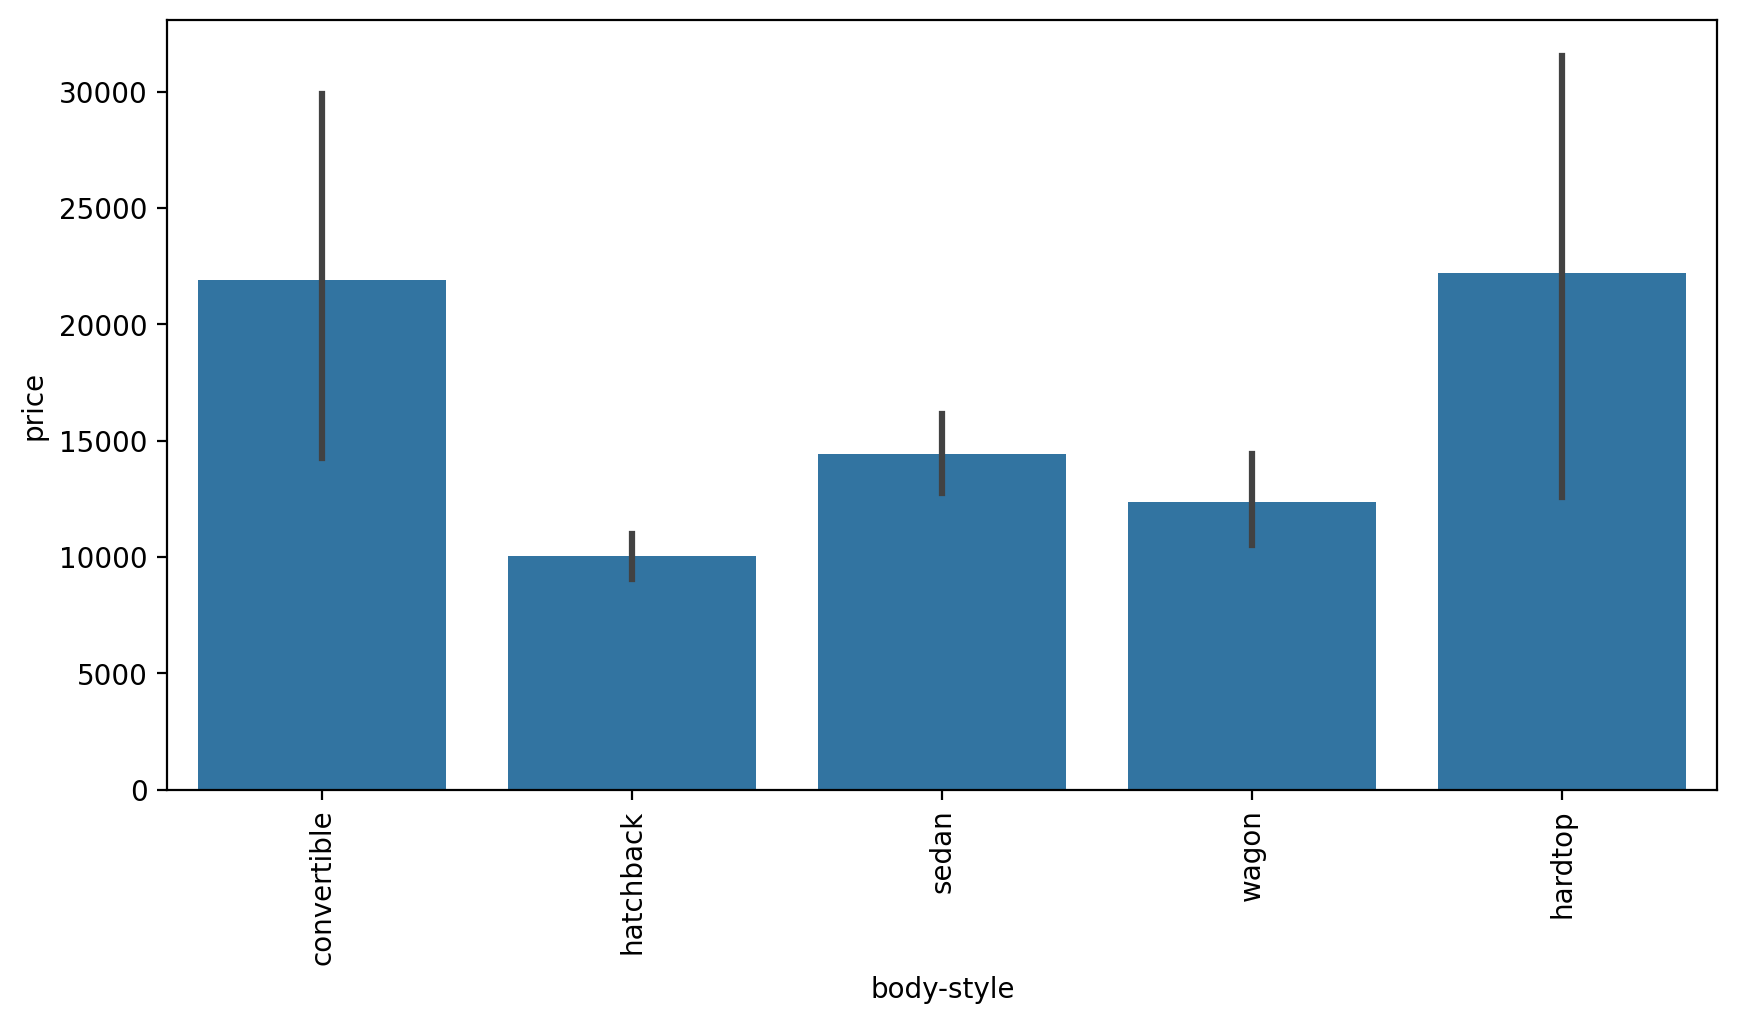

In [ ]:
plt.figure(figsize=(10,5),dpi=200)
sns.barplot(x='body-style',y='price',data=data)
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='body-style', ylabel='price'>

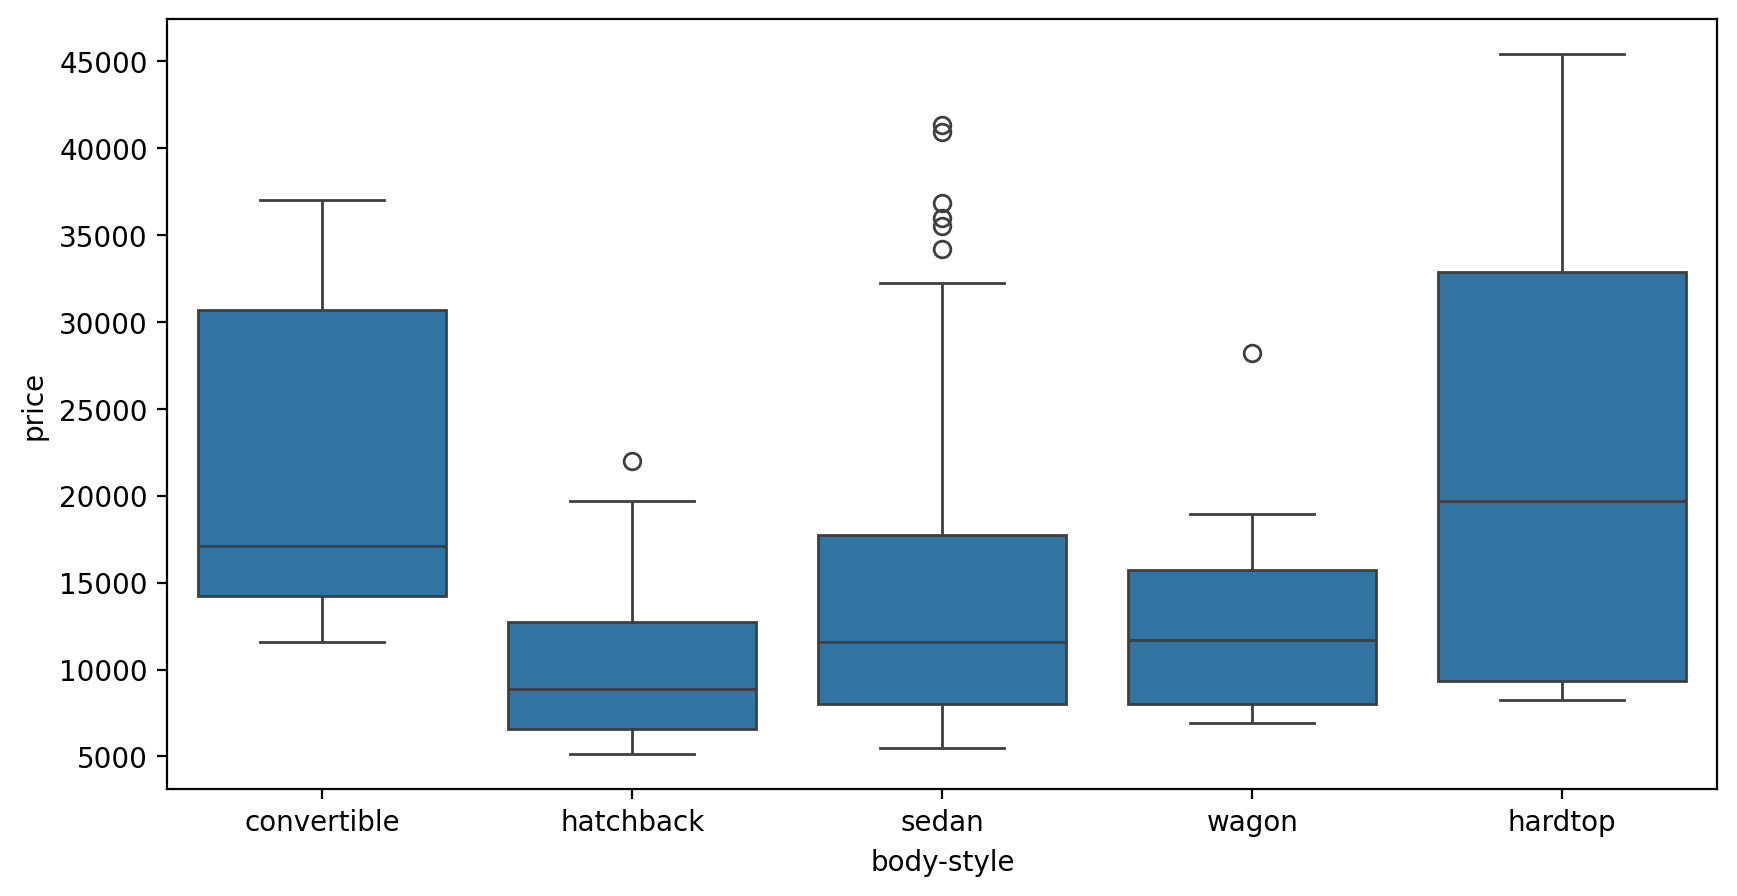

In [ ]:
plt.figure(figsize=(10,5),dpi=200)
sns.boxplot(x='body-style',y='price',data=data)

<Axes: xlabel='body-style', ylabel='price'>

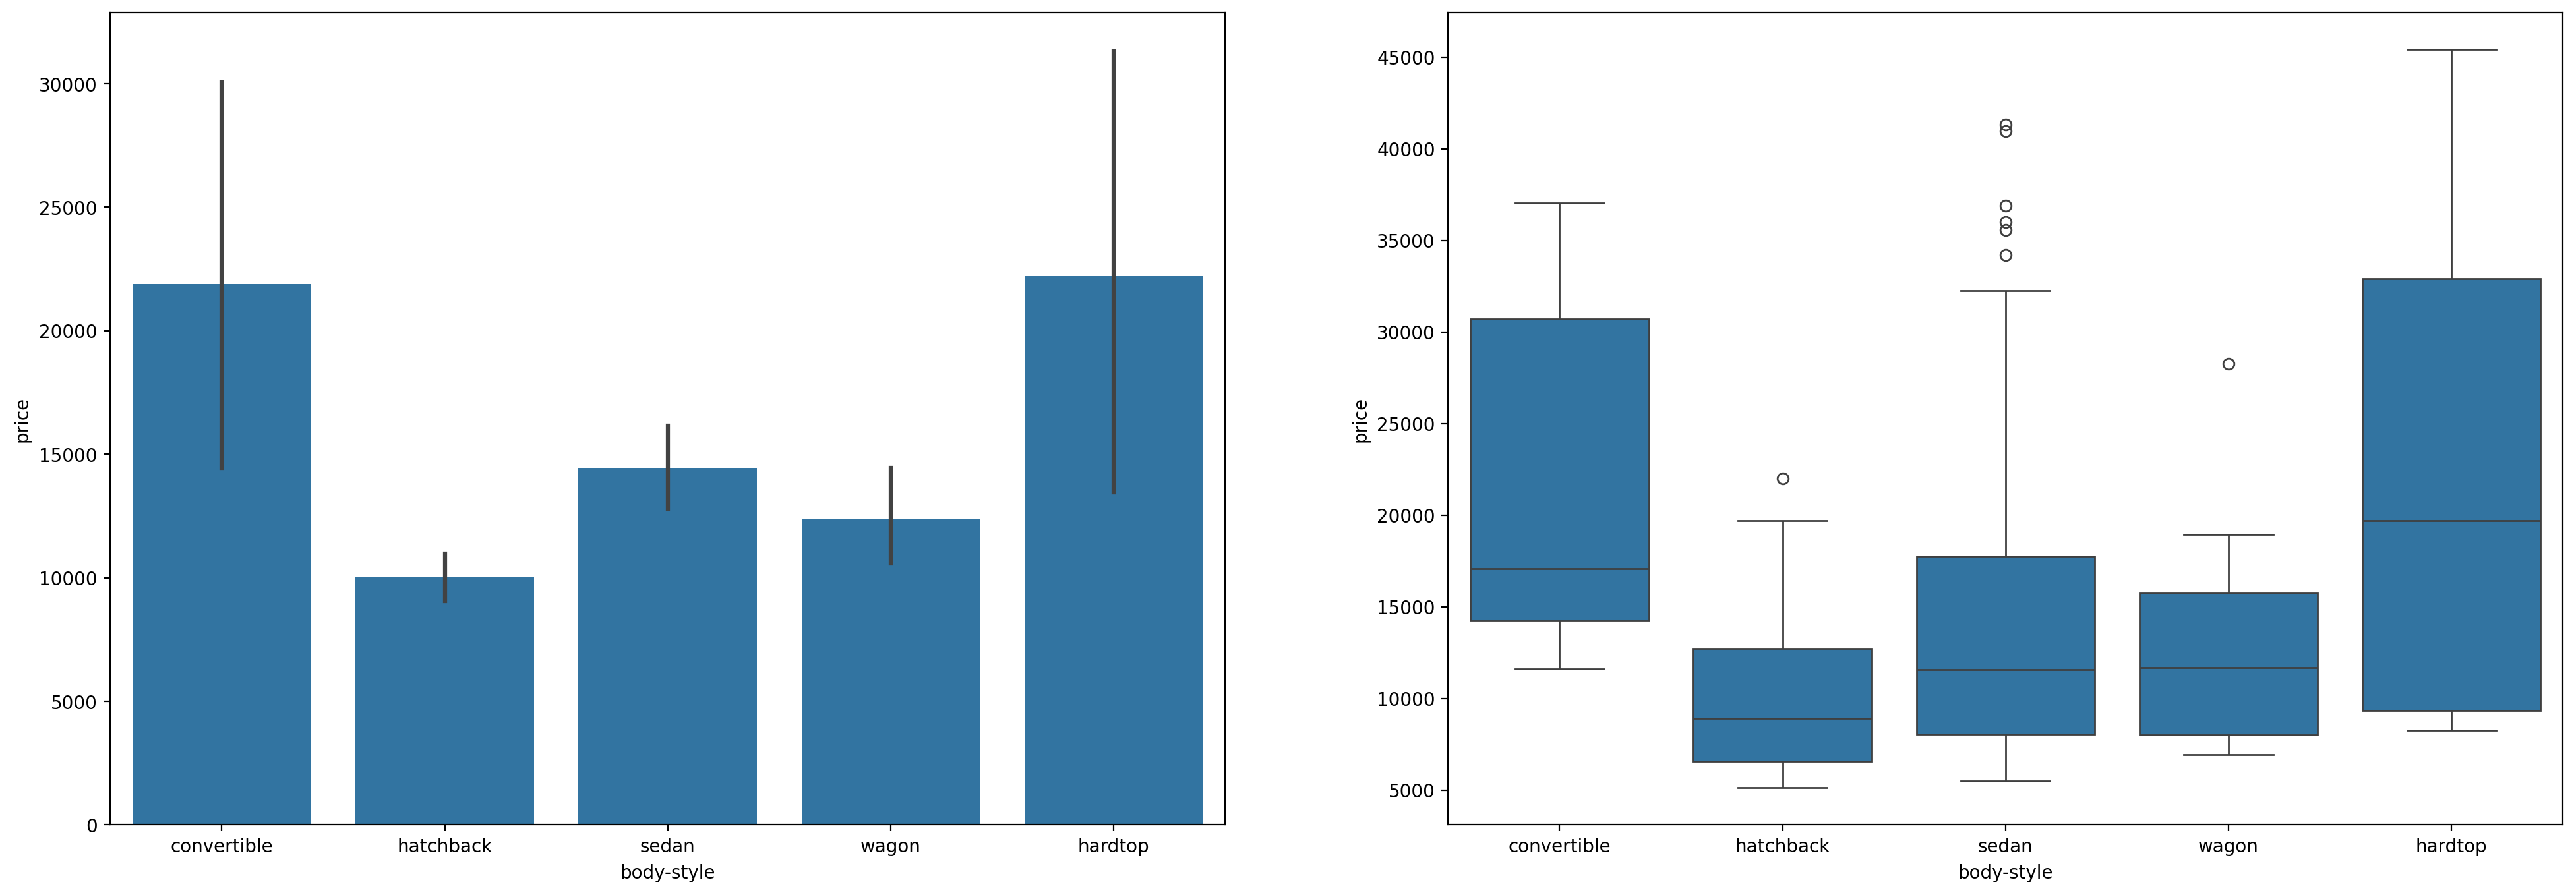

In [ ]:
plt.figure(figsize=(24,8),dpi=200)
plt.subplot(1,2,1)
sns.barplot(x='body-style',y='price',data=data)
plt.subplot(1,2,2)
sns.boxplot(x='body-style',y='price',data=data)

In [ ]:
# av horsepower wrt make
data.groupby('make')['horsepower'].mean().sort_values(ascending=False)

,horsepower
make,
porsche,210.400000
jaguar,204.666667
mercury,175.000000
mercedes-benz,146.250000
bmw,138.875000
volvo,128.000000
saab,126.666667
alfa-romero,125.333333
audi,121.000000


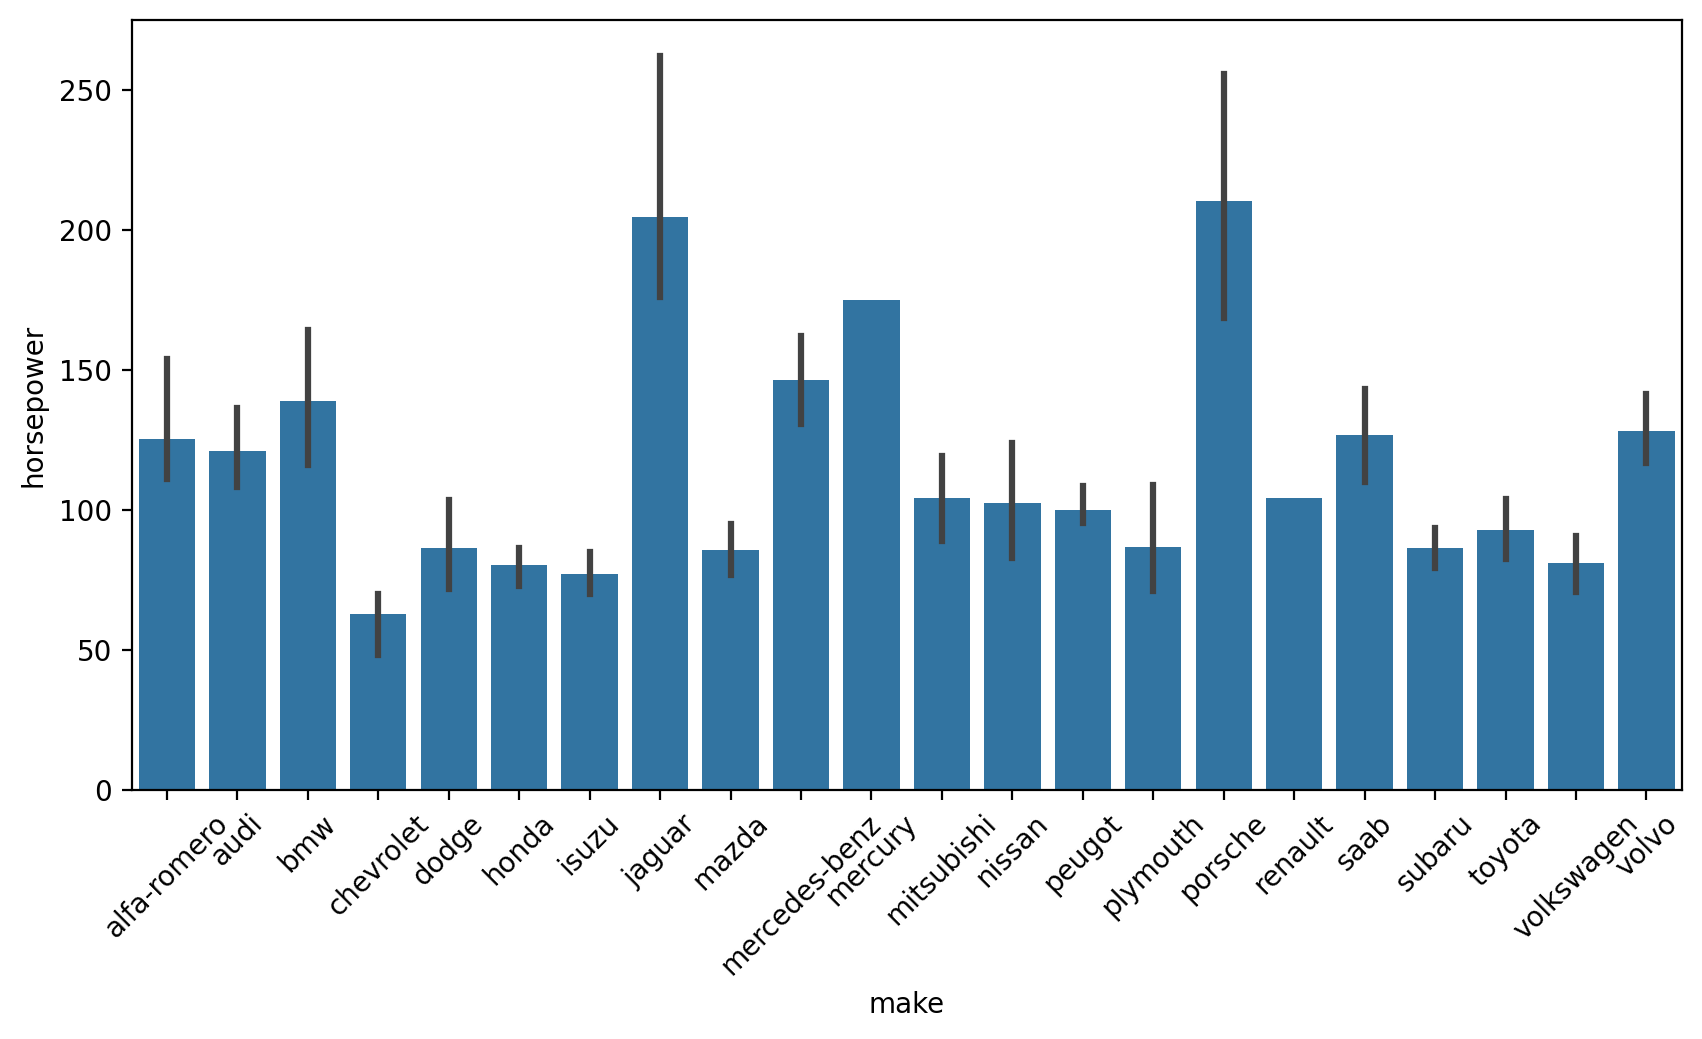

In [ ]:
plt.figure(figsize=(10,5),dpi=200)
sns.barplot(x='make',y='horsepower',data=data)
plt.xticks(rotation=45)
plt.show()

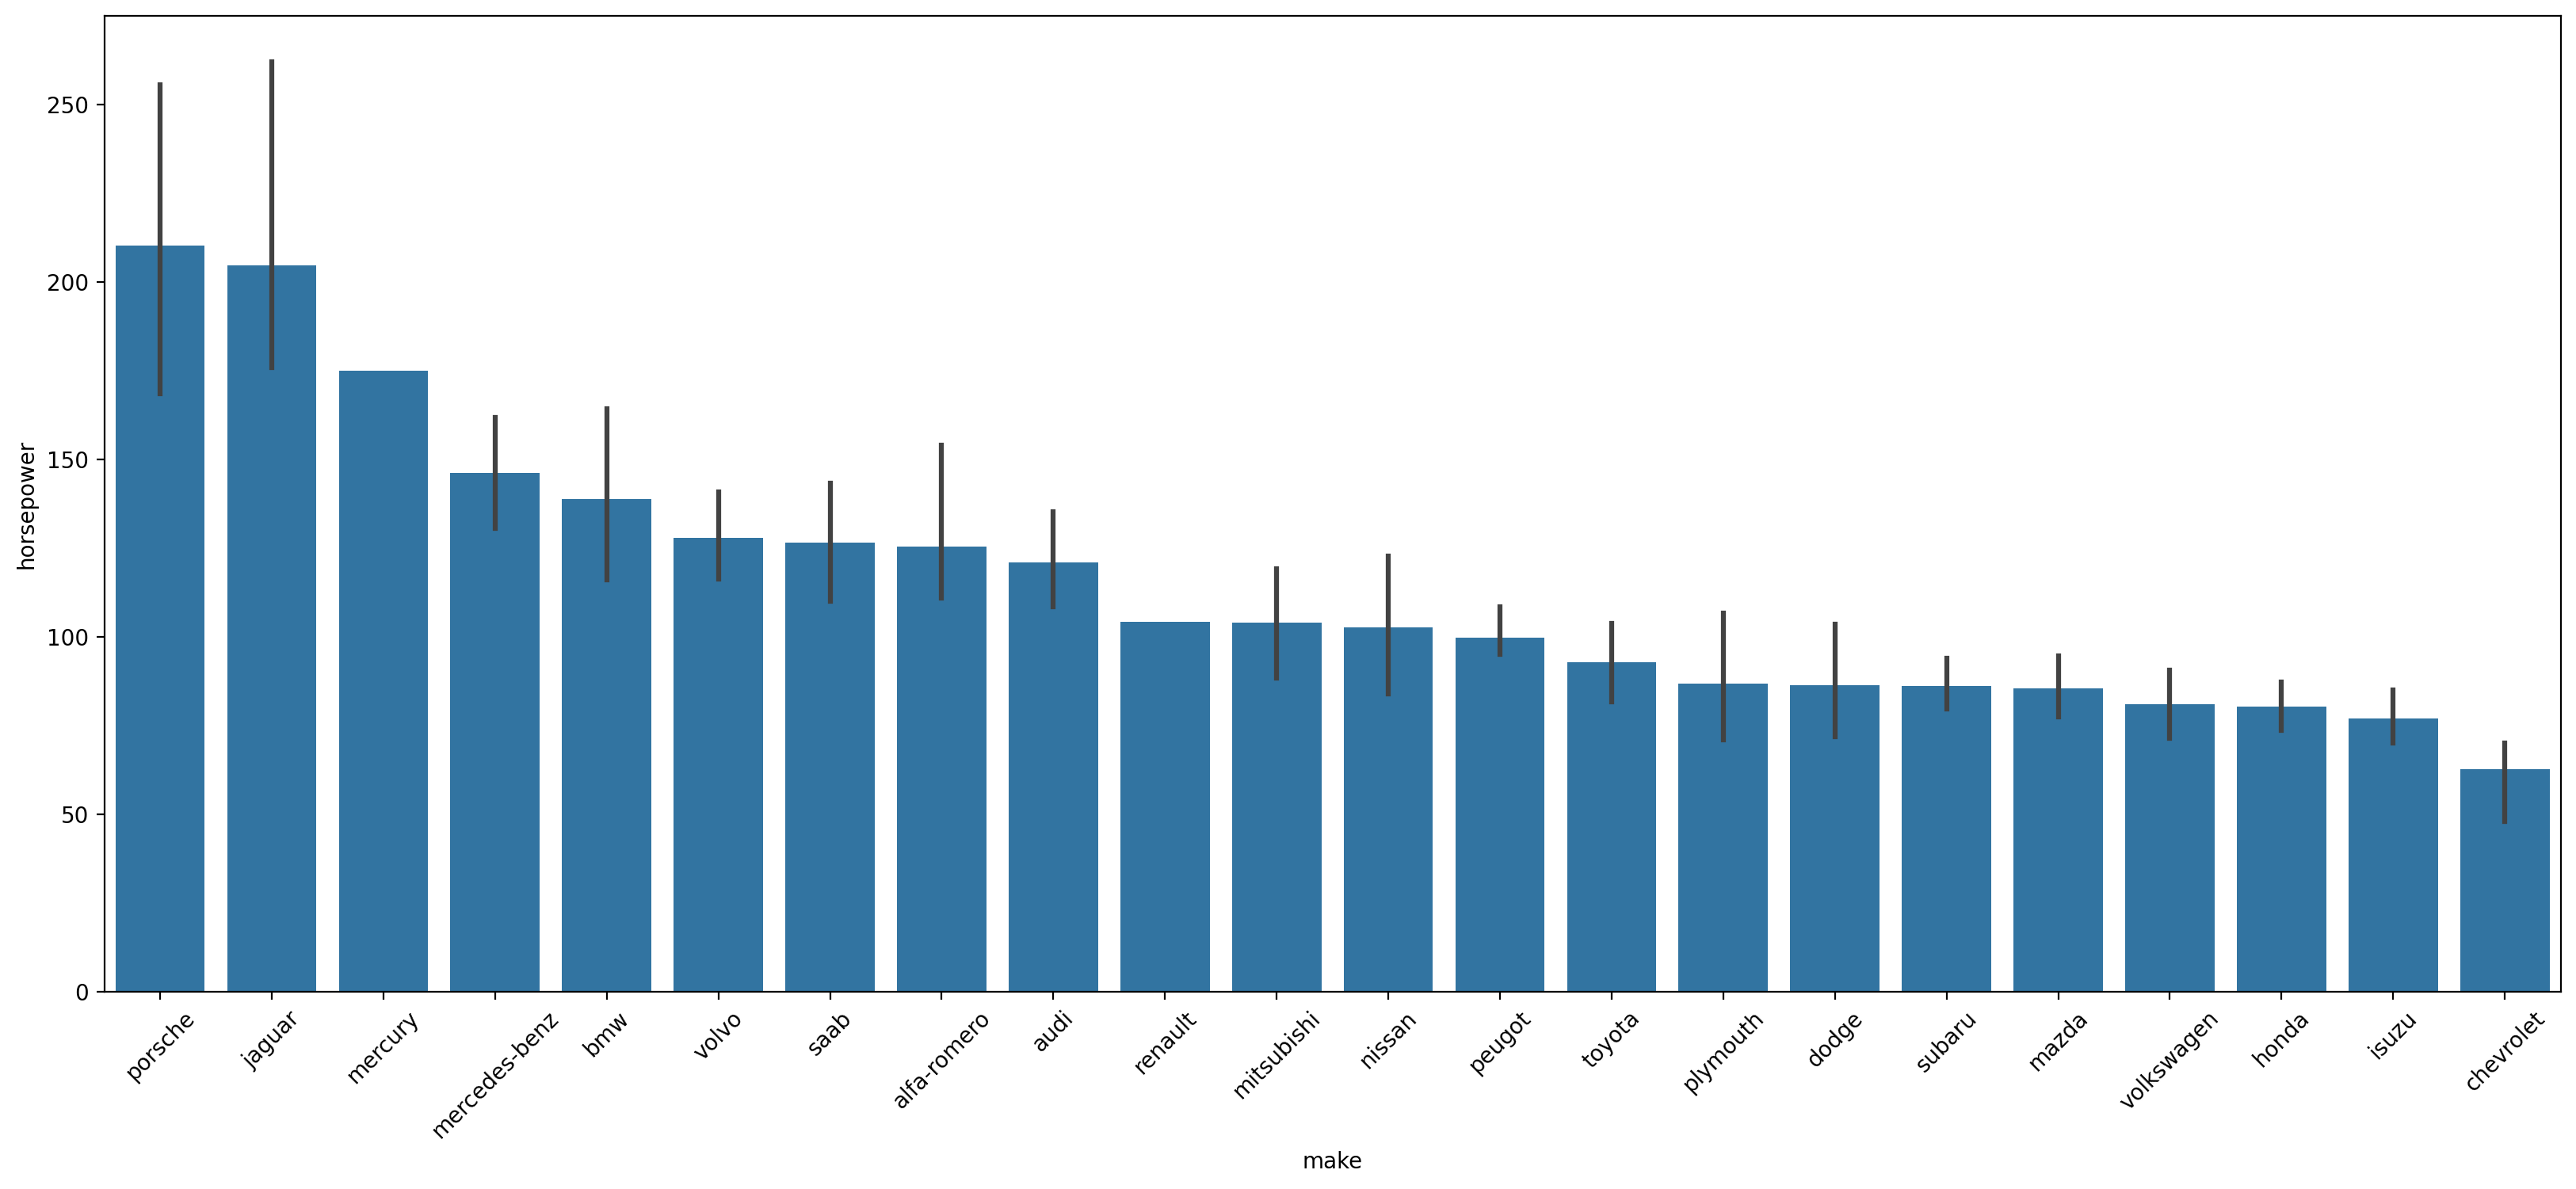

In [ ]:
des_order = data.groupby('make')['horsepower'].mean().sort_values(ascending=False).index
plt.figure(figsize=(20,8),dpi=200)
sns.barplot(x='make',y='horsepower',data=data,order=des_order)
plt.xticks(rotation=45)
plt.show()

In [ ]:
#how many vehicle for each body type
data['body-style'].value_counts()

,count
body-style,
sedan,96
hatchback,70
wagon,25
hardtop,8
convertible,6


<Axes: xlabel='body-style', ylabel='count'>

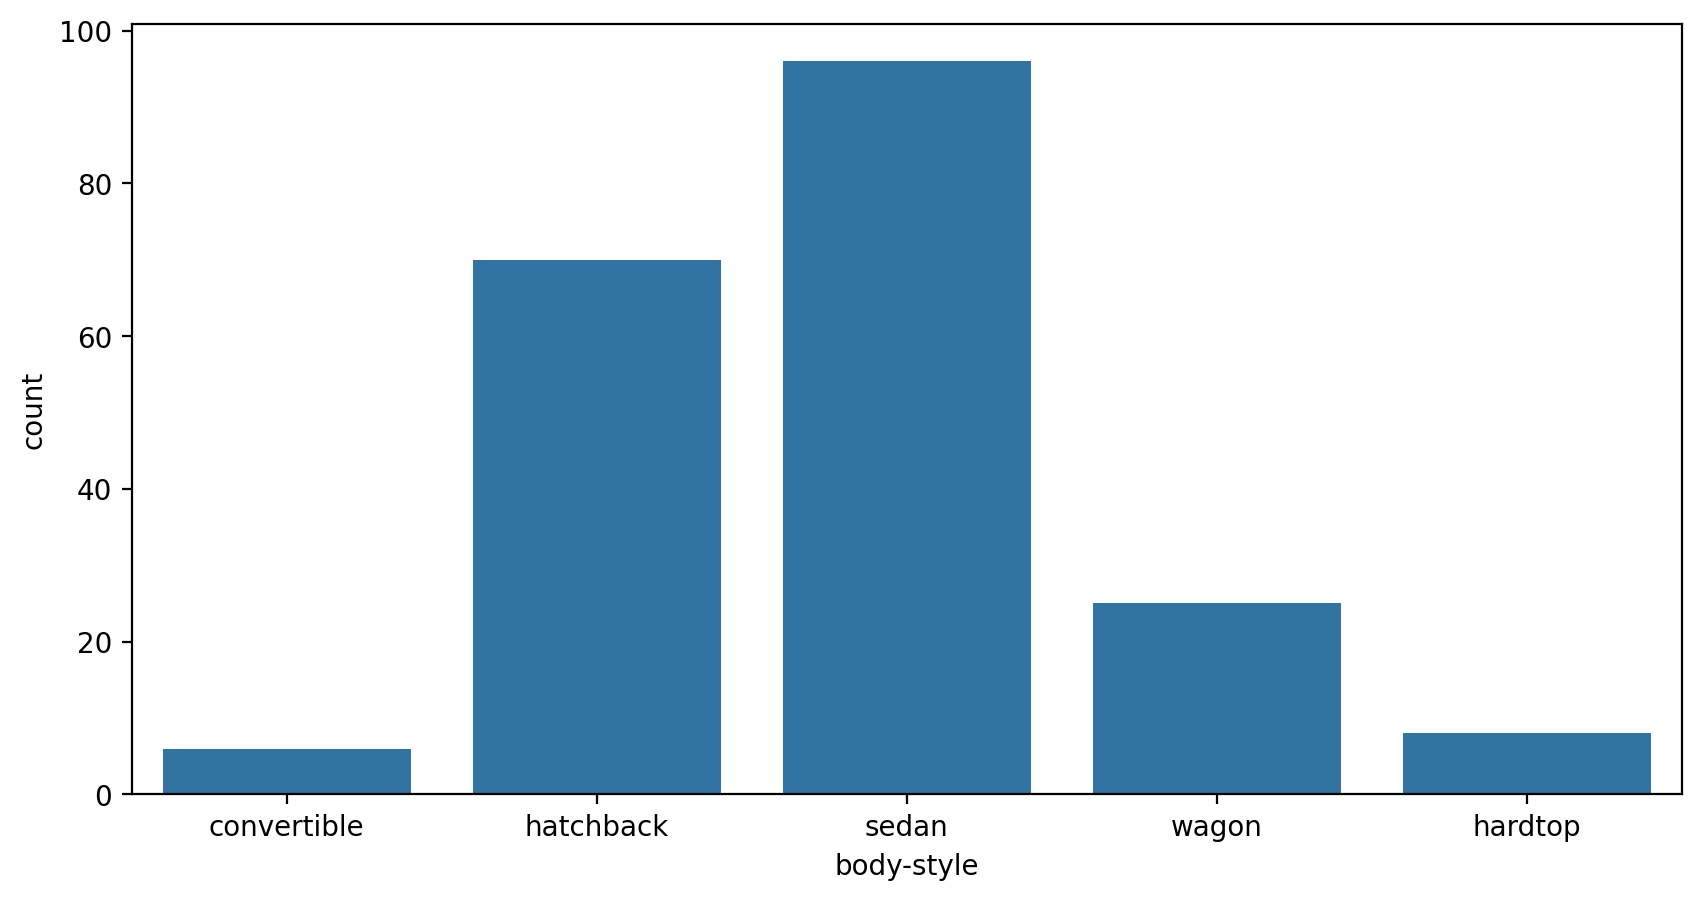

In [ ]:
plt.figure(figsize=(10,5),dpi=200)
sns.countplot(x='body-style',data=data)

<Axes: xlabel='horsepower', ylabel='cmb_mpg'>

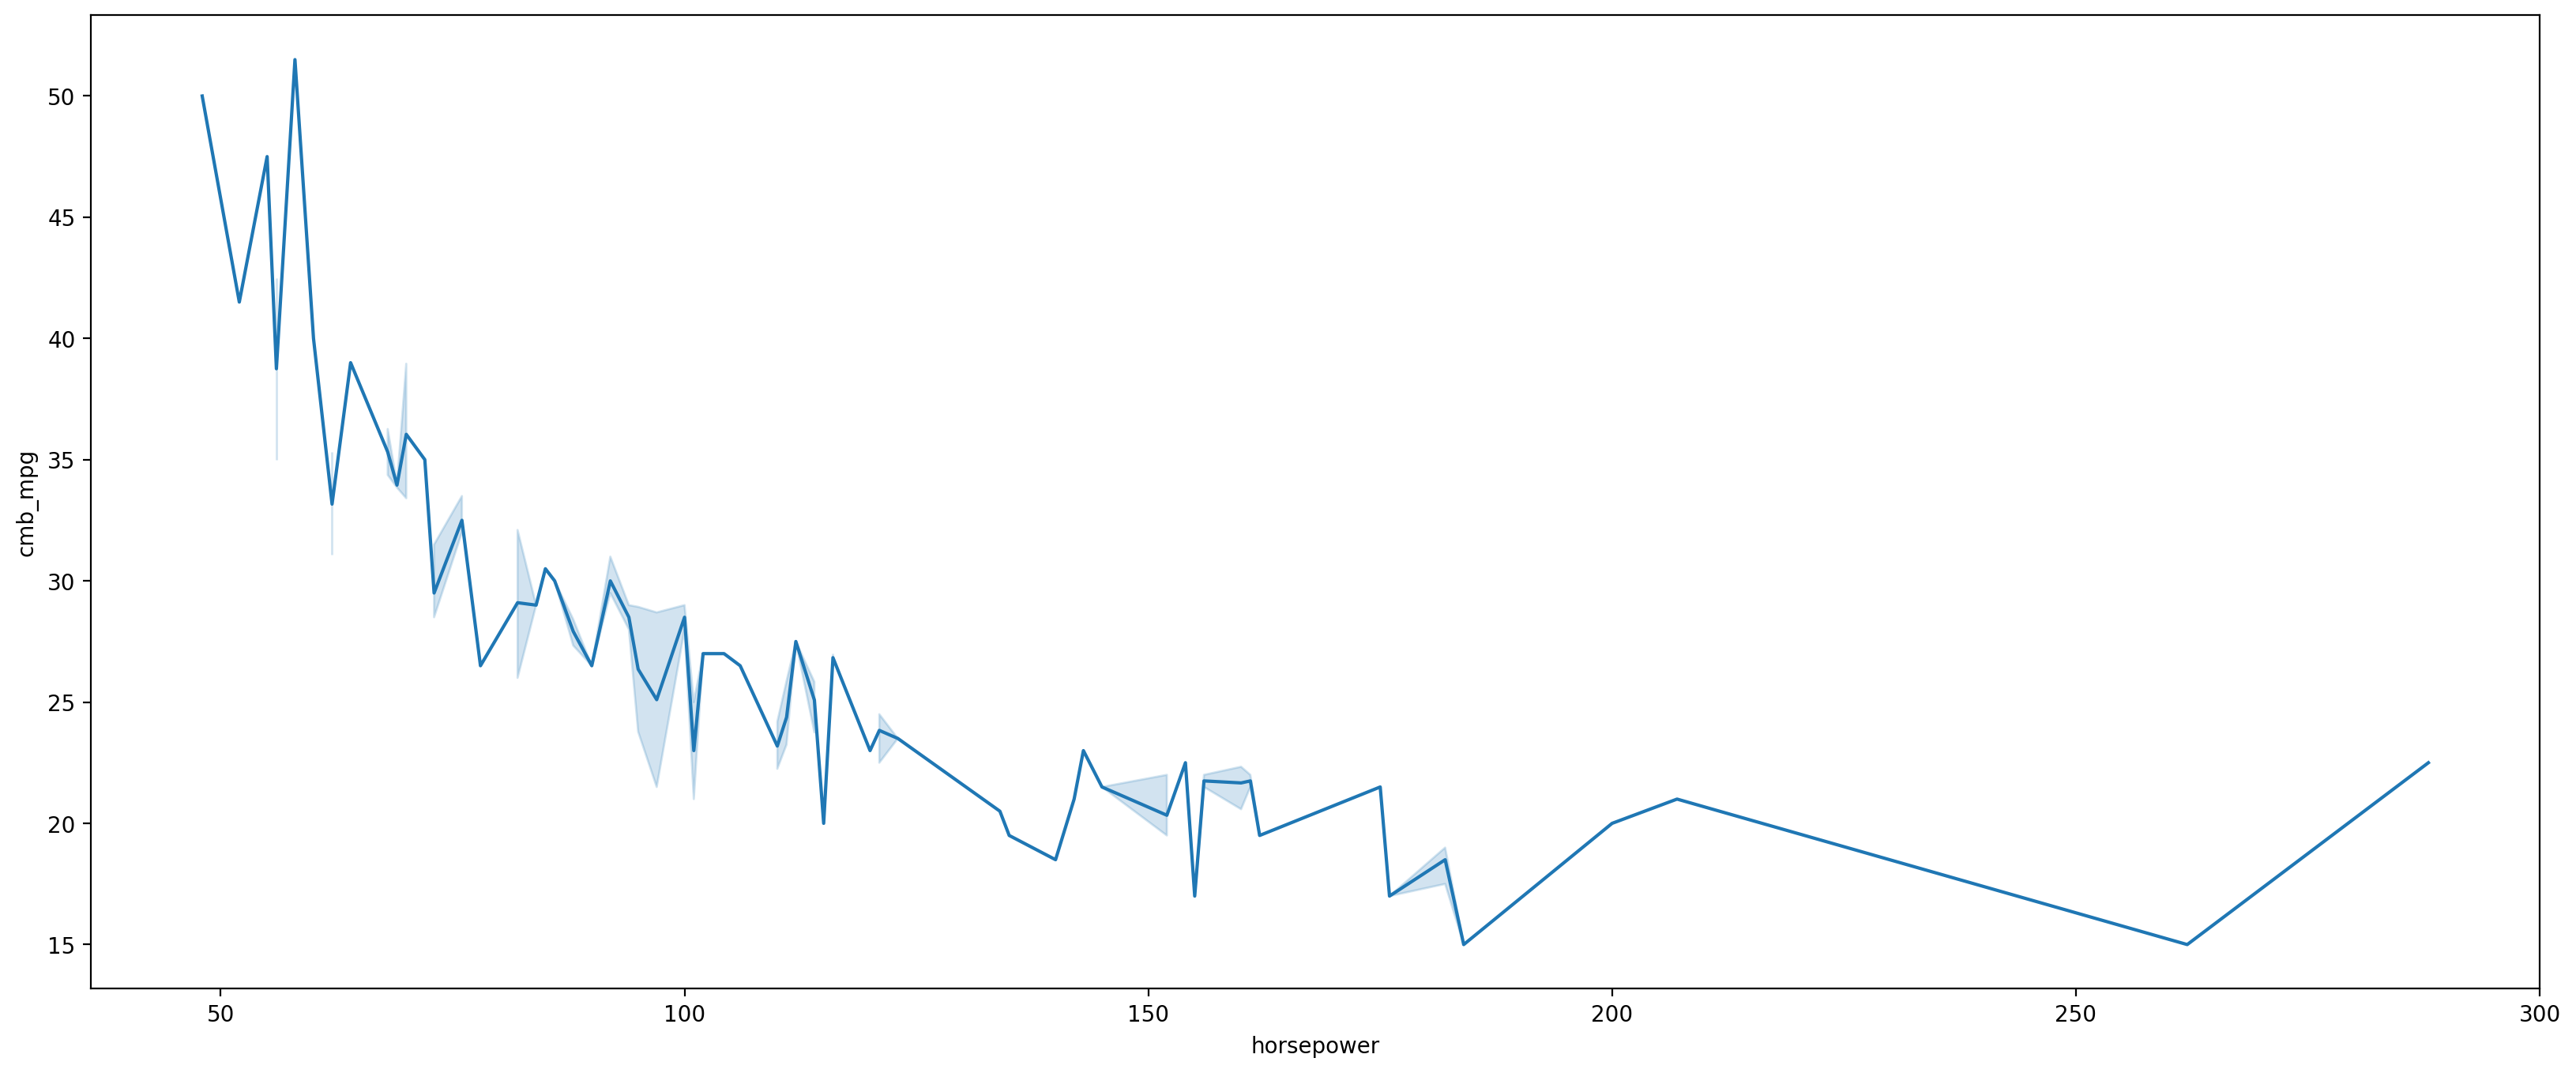

In [ ]:
# power and milage
plt.figure(figsize=(20,8),dpi=200)
sns.lineplot(x='horsepower',y='cmb_mpg',data=data)

<Axes: xlabel='body-style', ylabel='horsepower'>

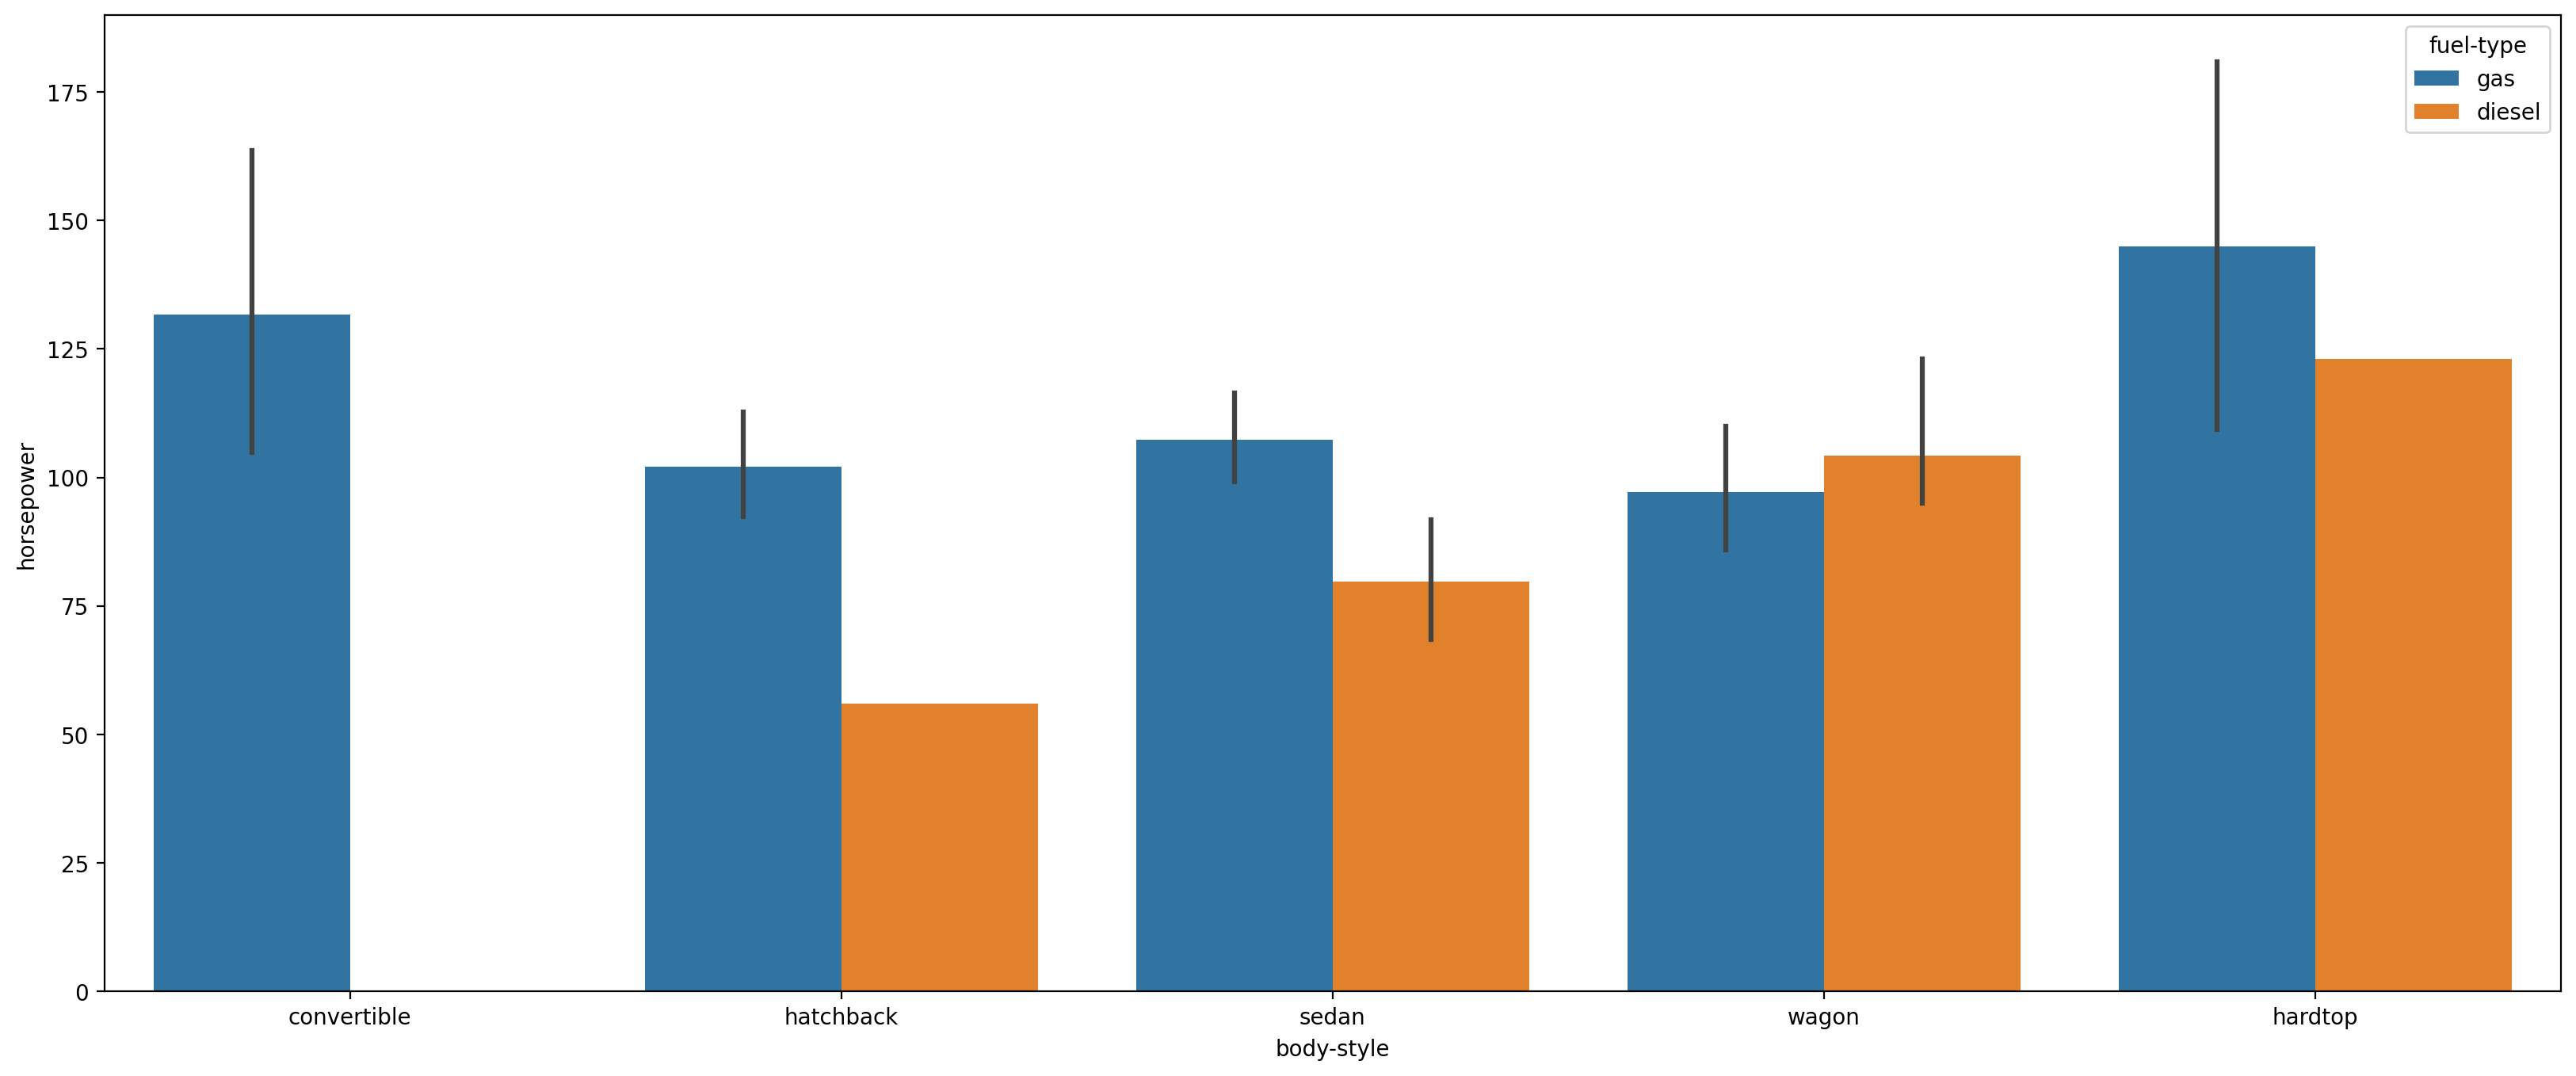

In [ ]:
#body type and power
plt.figure(figsize=(20,8),dpi=200)
sns.barplot(x='body-style',y='horsepower',data=data, hue='fuel-type')


<Axes: xlabel='fuel-type', ylabel='cmb_mpg'>

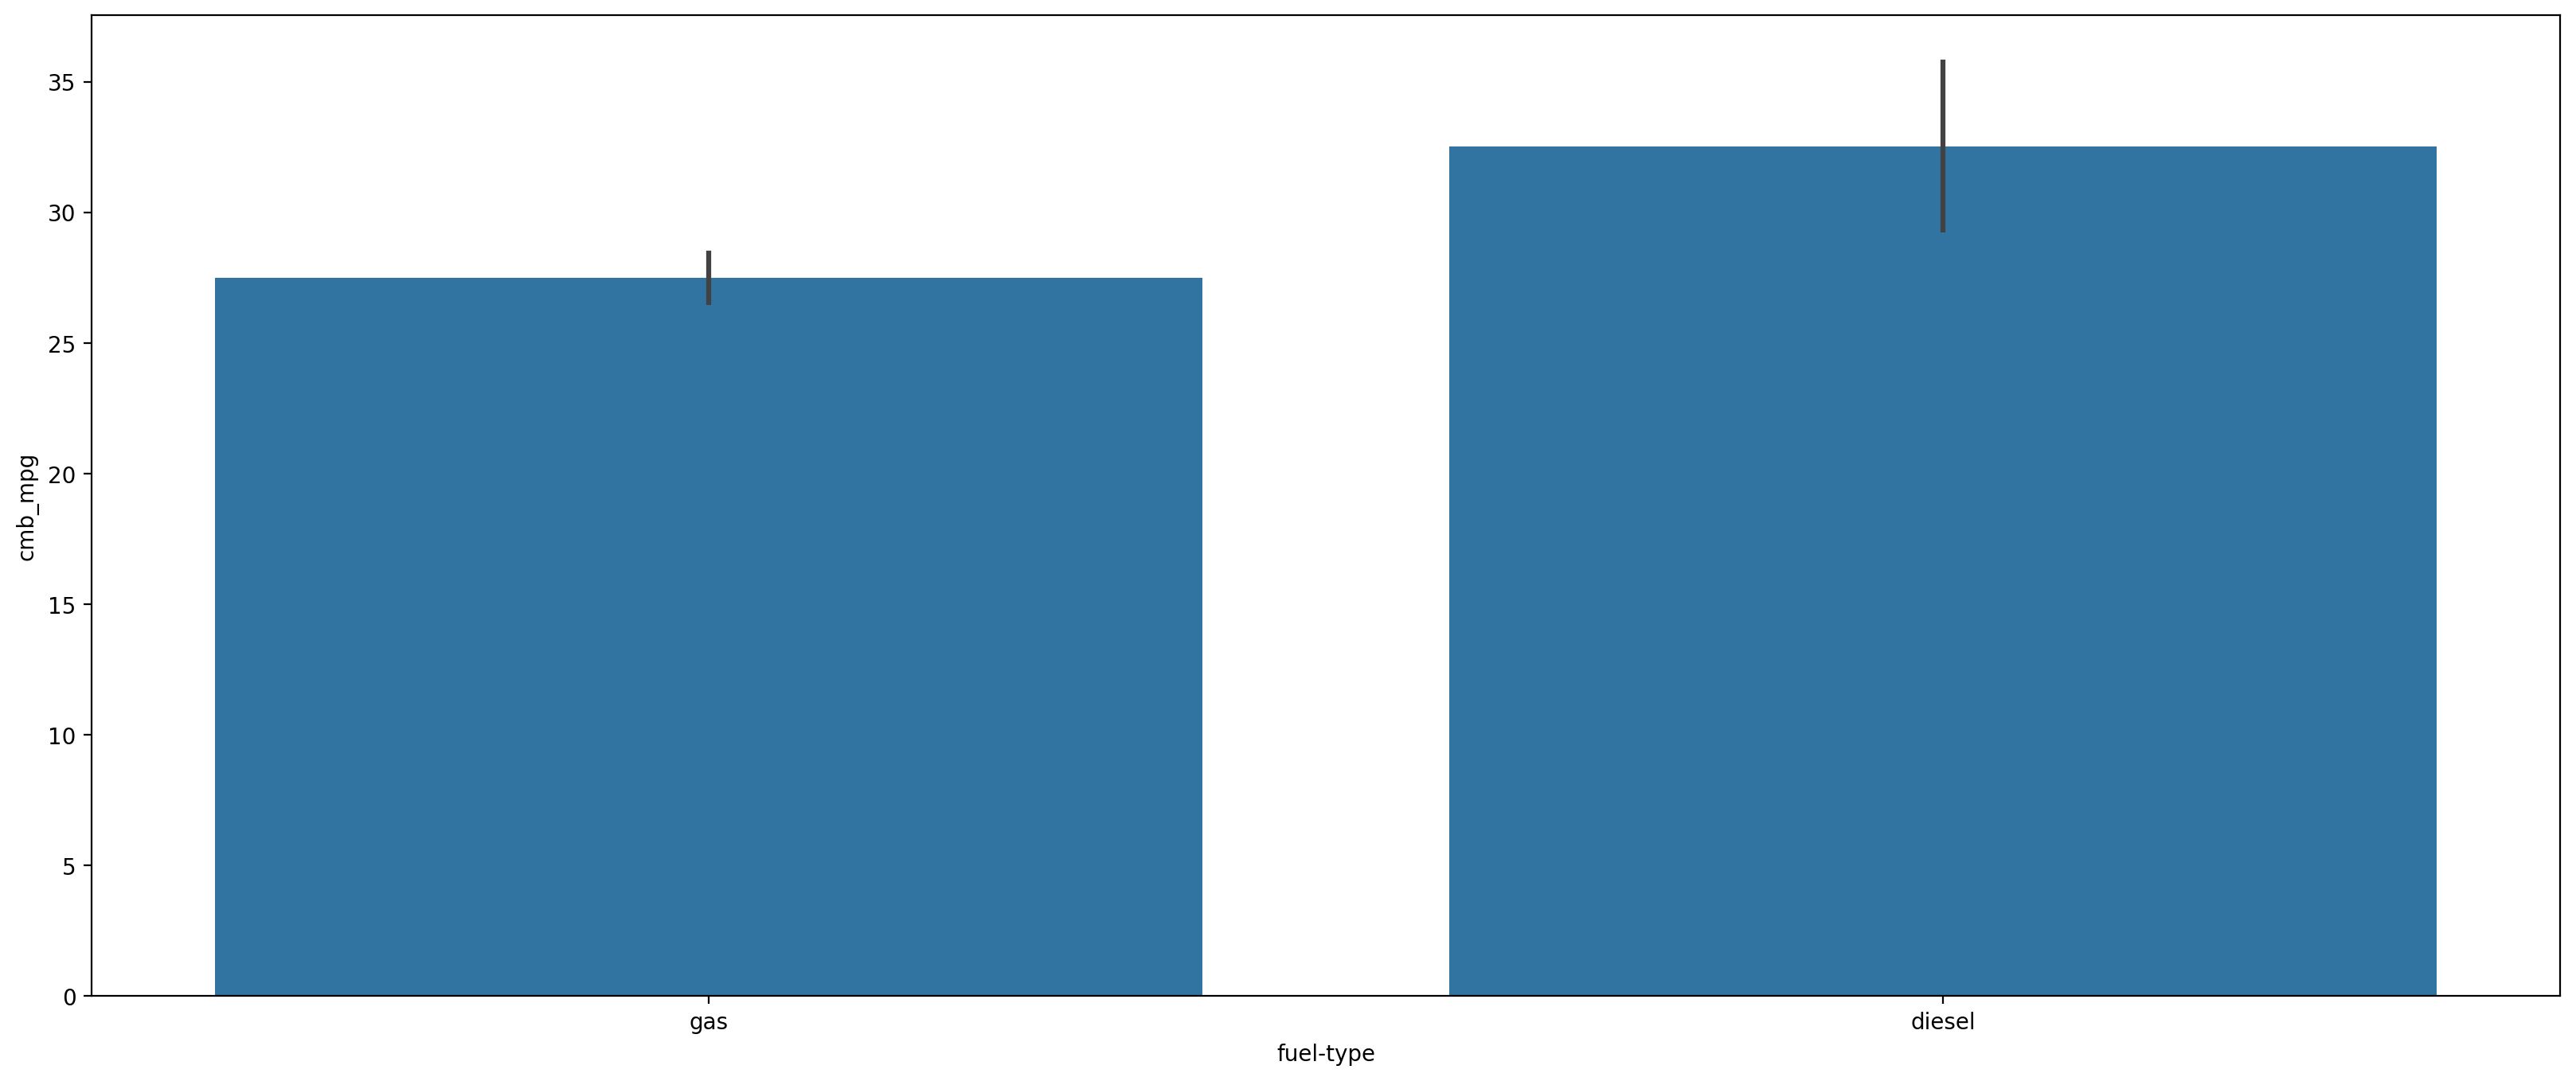

In [ ]:
# which fuel is more efficient
plt.figure(figsize=(20,8),dpi=200)
sns.barplot(x='fuel-type',y='cmb_mpg',data=data)

<Axes: xlabel='curb-weight', ylabel='cmb_mpg'>

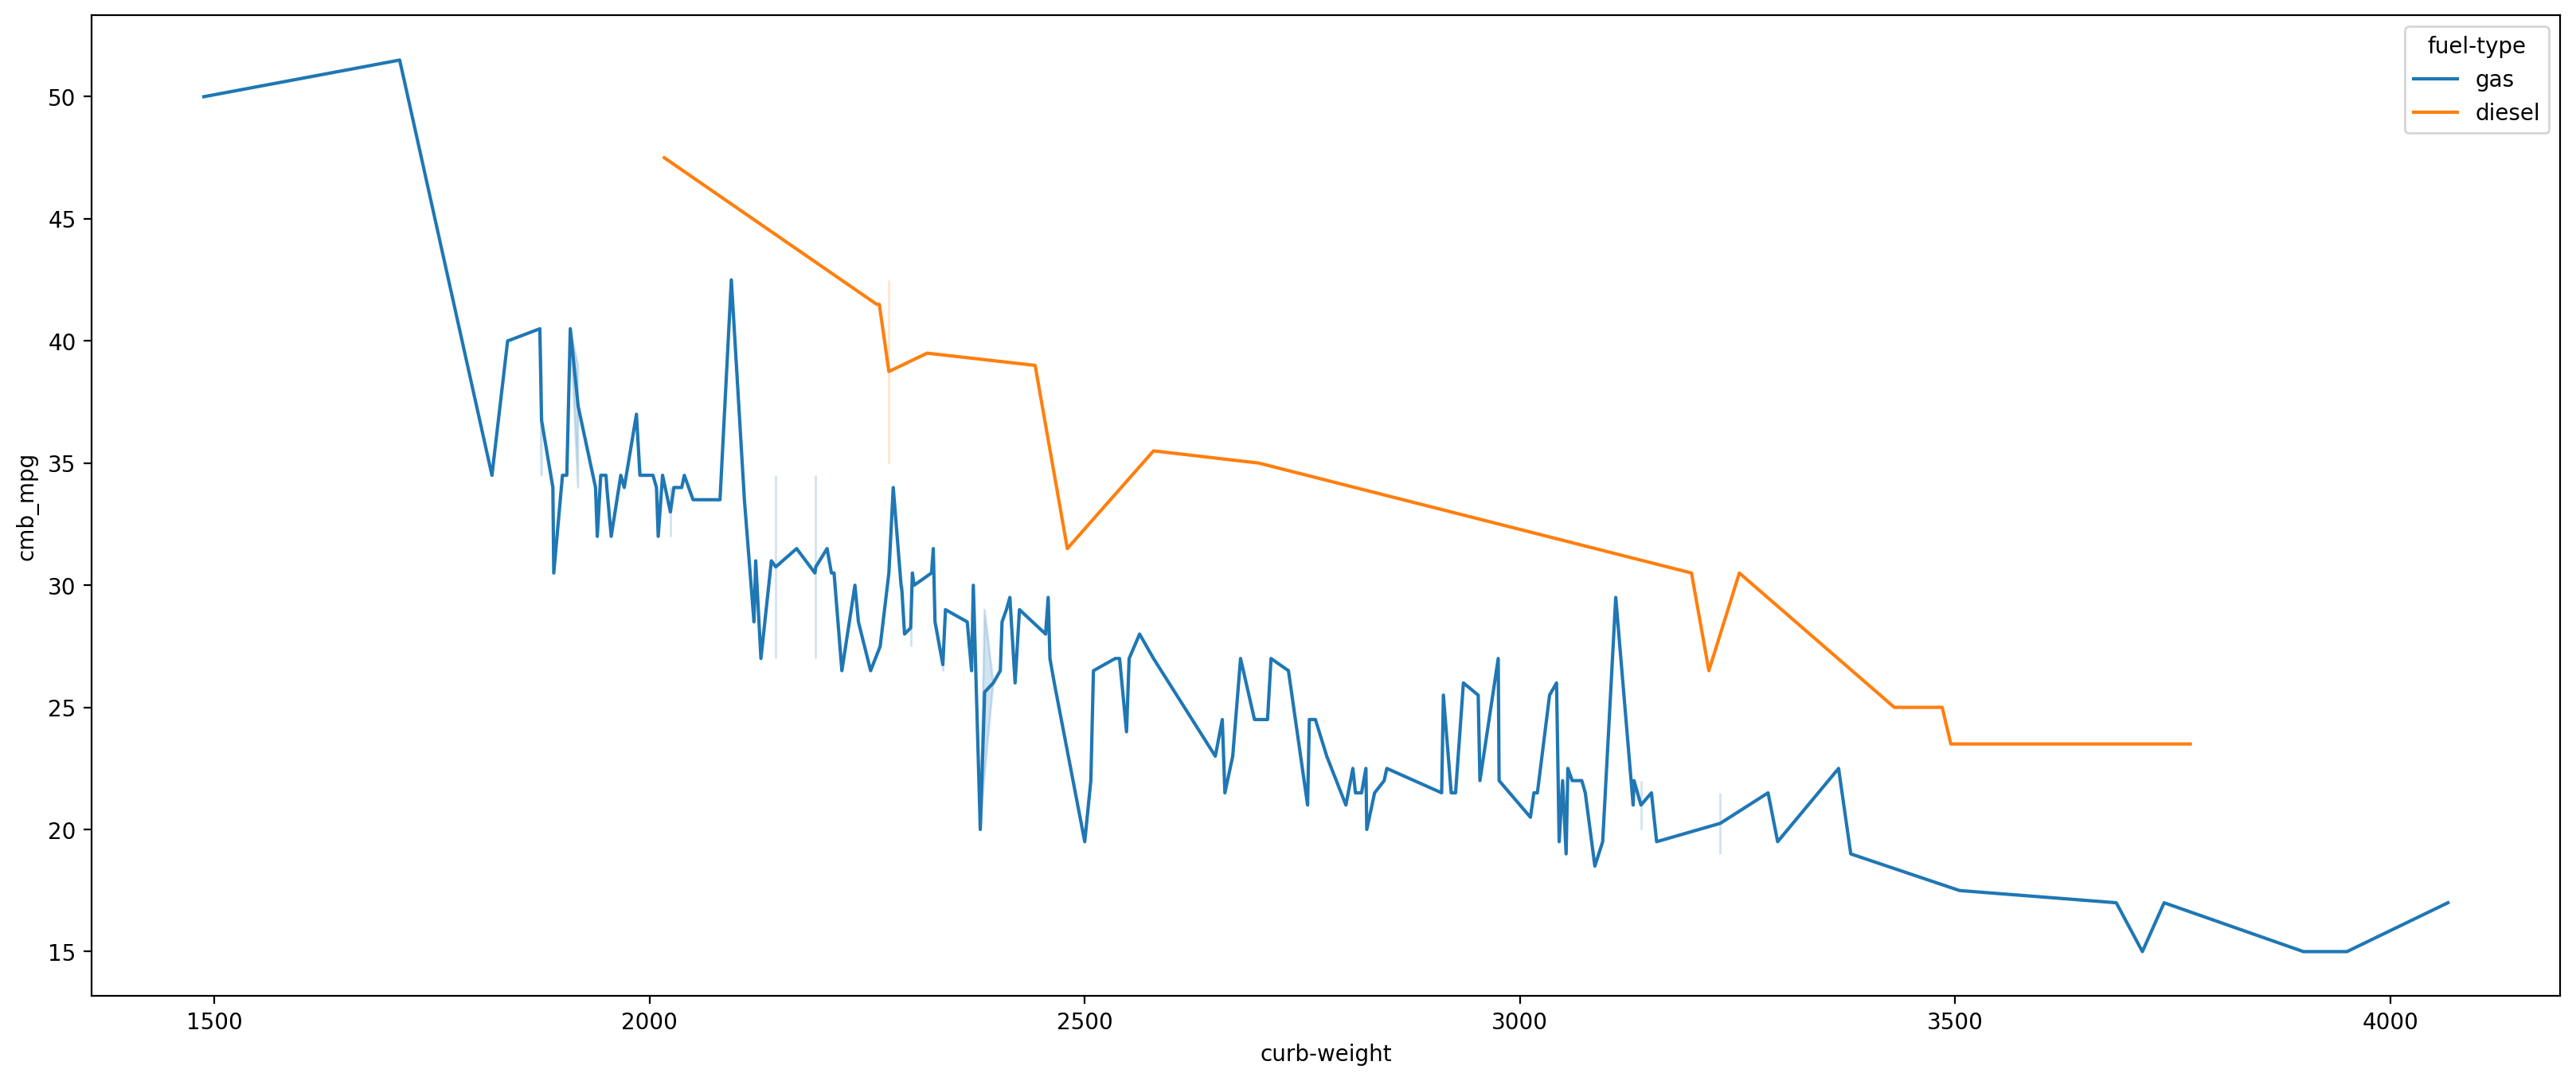

In [ ]:
plt.figure(figsize=(20,8),dpi=200)
sns.lineplot(x='curb-weight',y='cmb_mpg', hue='fuel-type',data=data)

In [ ]:
data.columns

Index(['symboling', 'make', 'fuel-type', 'aspiration', 'num-of-doors',
       'body-style', 'drive-wheels', 'engine-location', 'wheel-base', 'length',
       'width', 'height', 'curb-weight', 'engine-type', 'num-of-cylinders',
       'engine-size', 'fuel-system', 'bore', 'stroke', 'compression-ratio',
       'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price',
       'cmb_mpg'],
      dtype='object')

<Axes: >

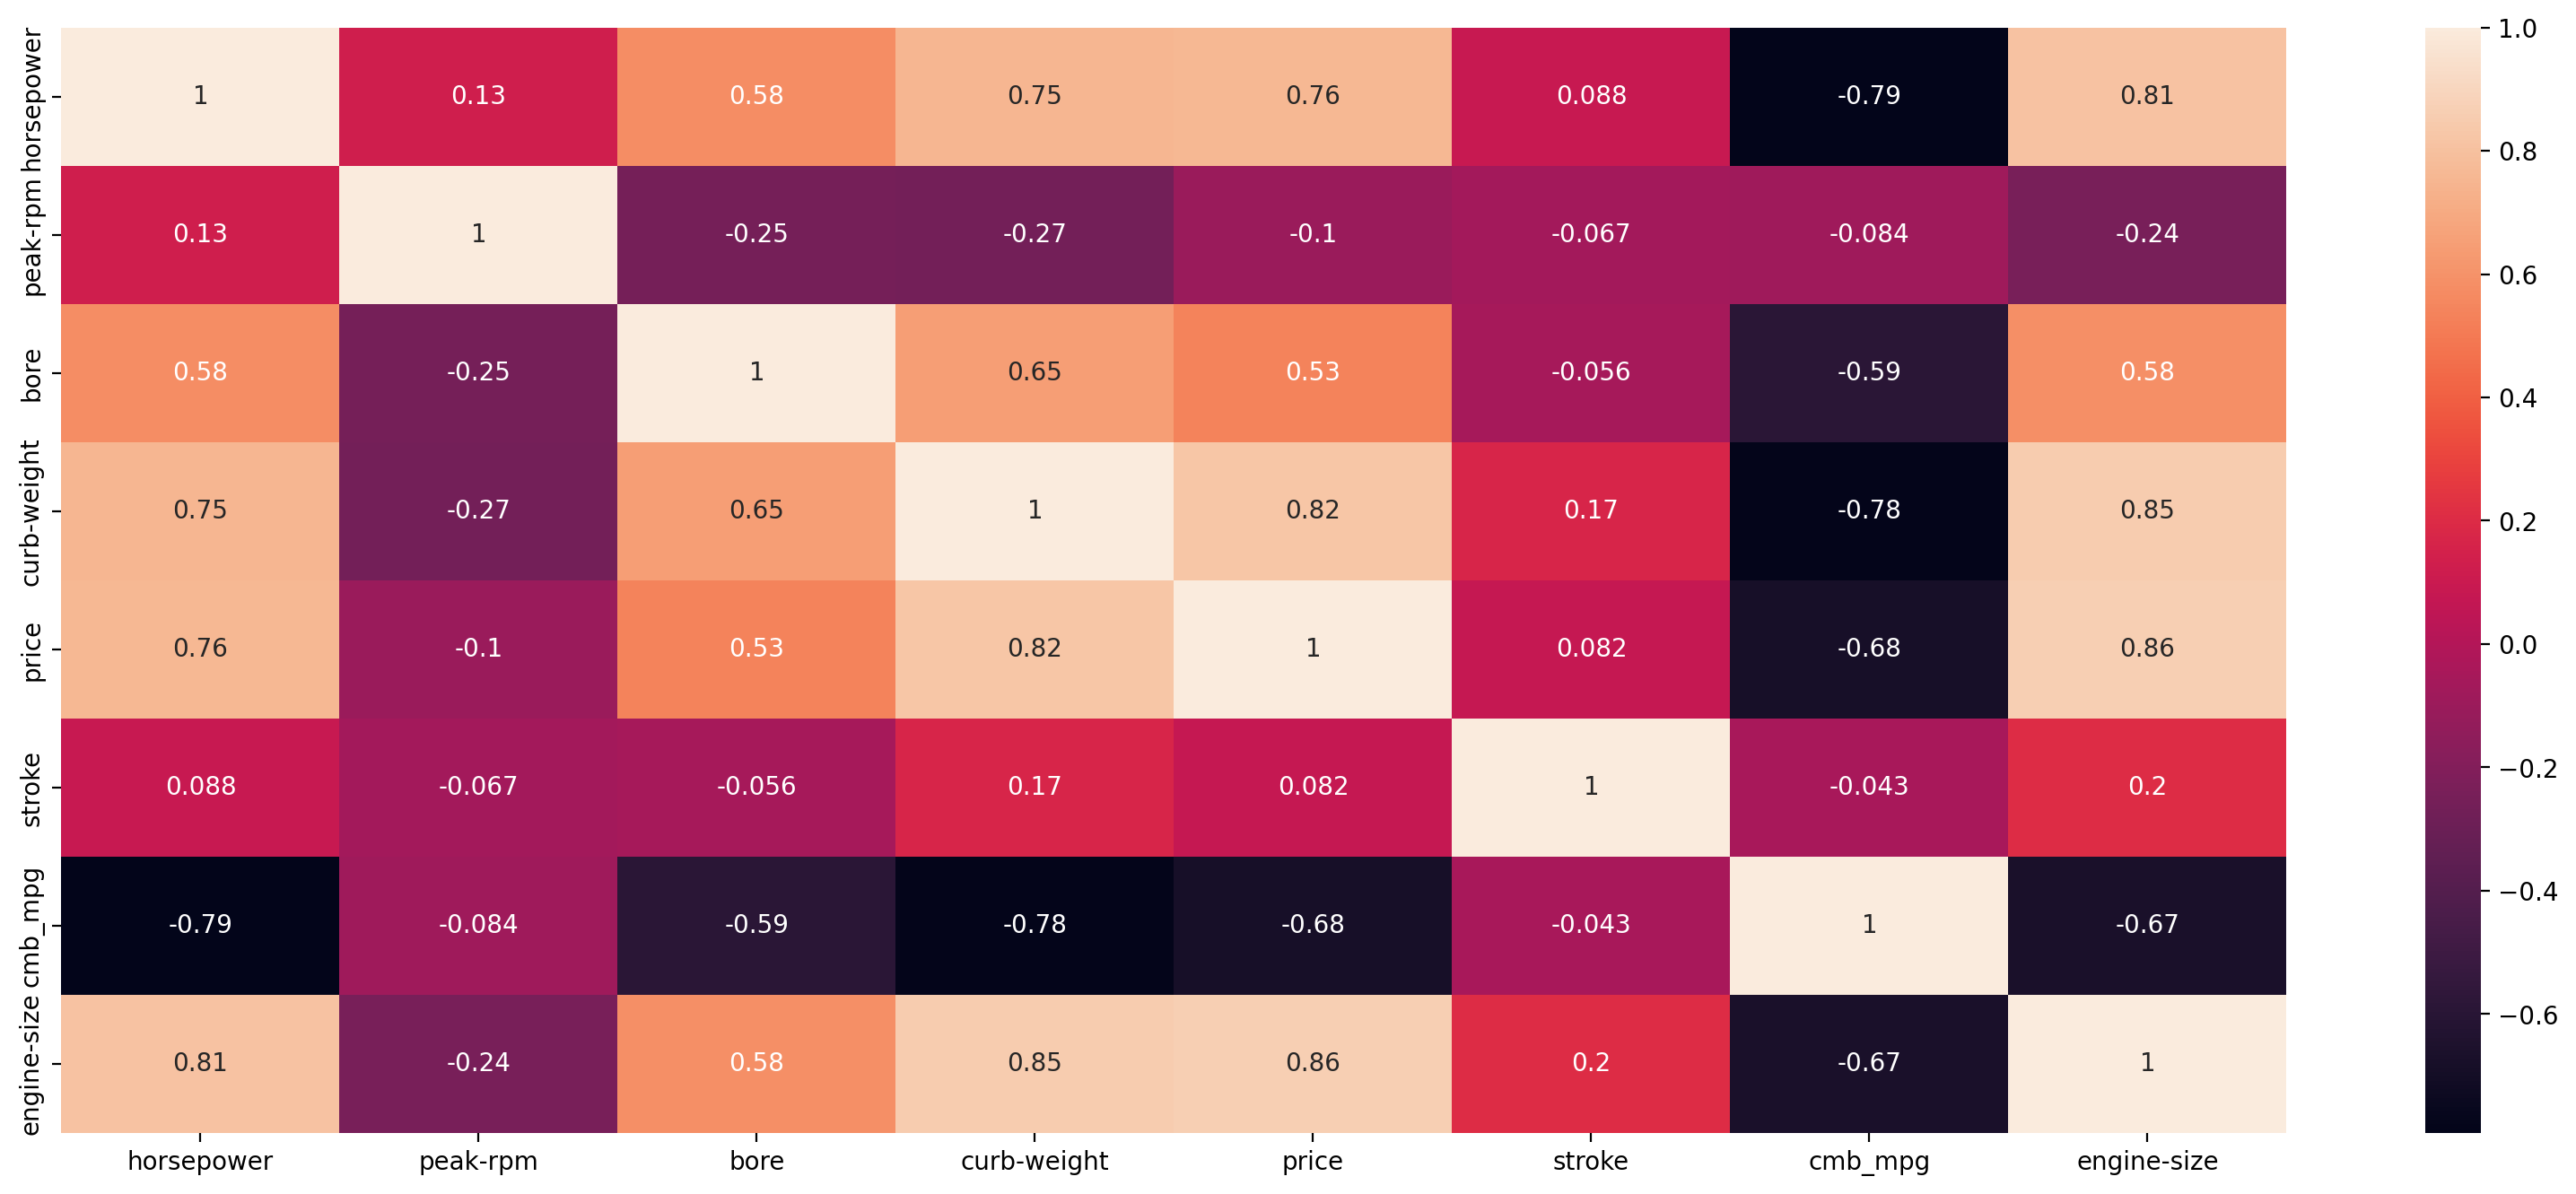

In [ ]:
#heat map
cols=[  'horsepower', 'peak-rpm', 'bore', 'curb-weight', 'price','stroke', 'cmb_mpg','engine-size']
plt.figure(figsize=(20,8),dpi=200)
sns.heatmap(data[cols].corr(),annot=True)


In [ ]:
#avg milage wrt fuel type and aspiration
data.groupby(['fuel-type','aspiration'])['cmb_mpg'].mean()

fuel-type  aspiration
diesel     std           40.285714
           turbo         28.346154
gas        std           28.201863
           turbo         22.750000
Name: cmb_mpg, dtype: float64

<Axes: xlabel='curb-weight', ylabel='cmb_mpg'>

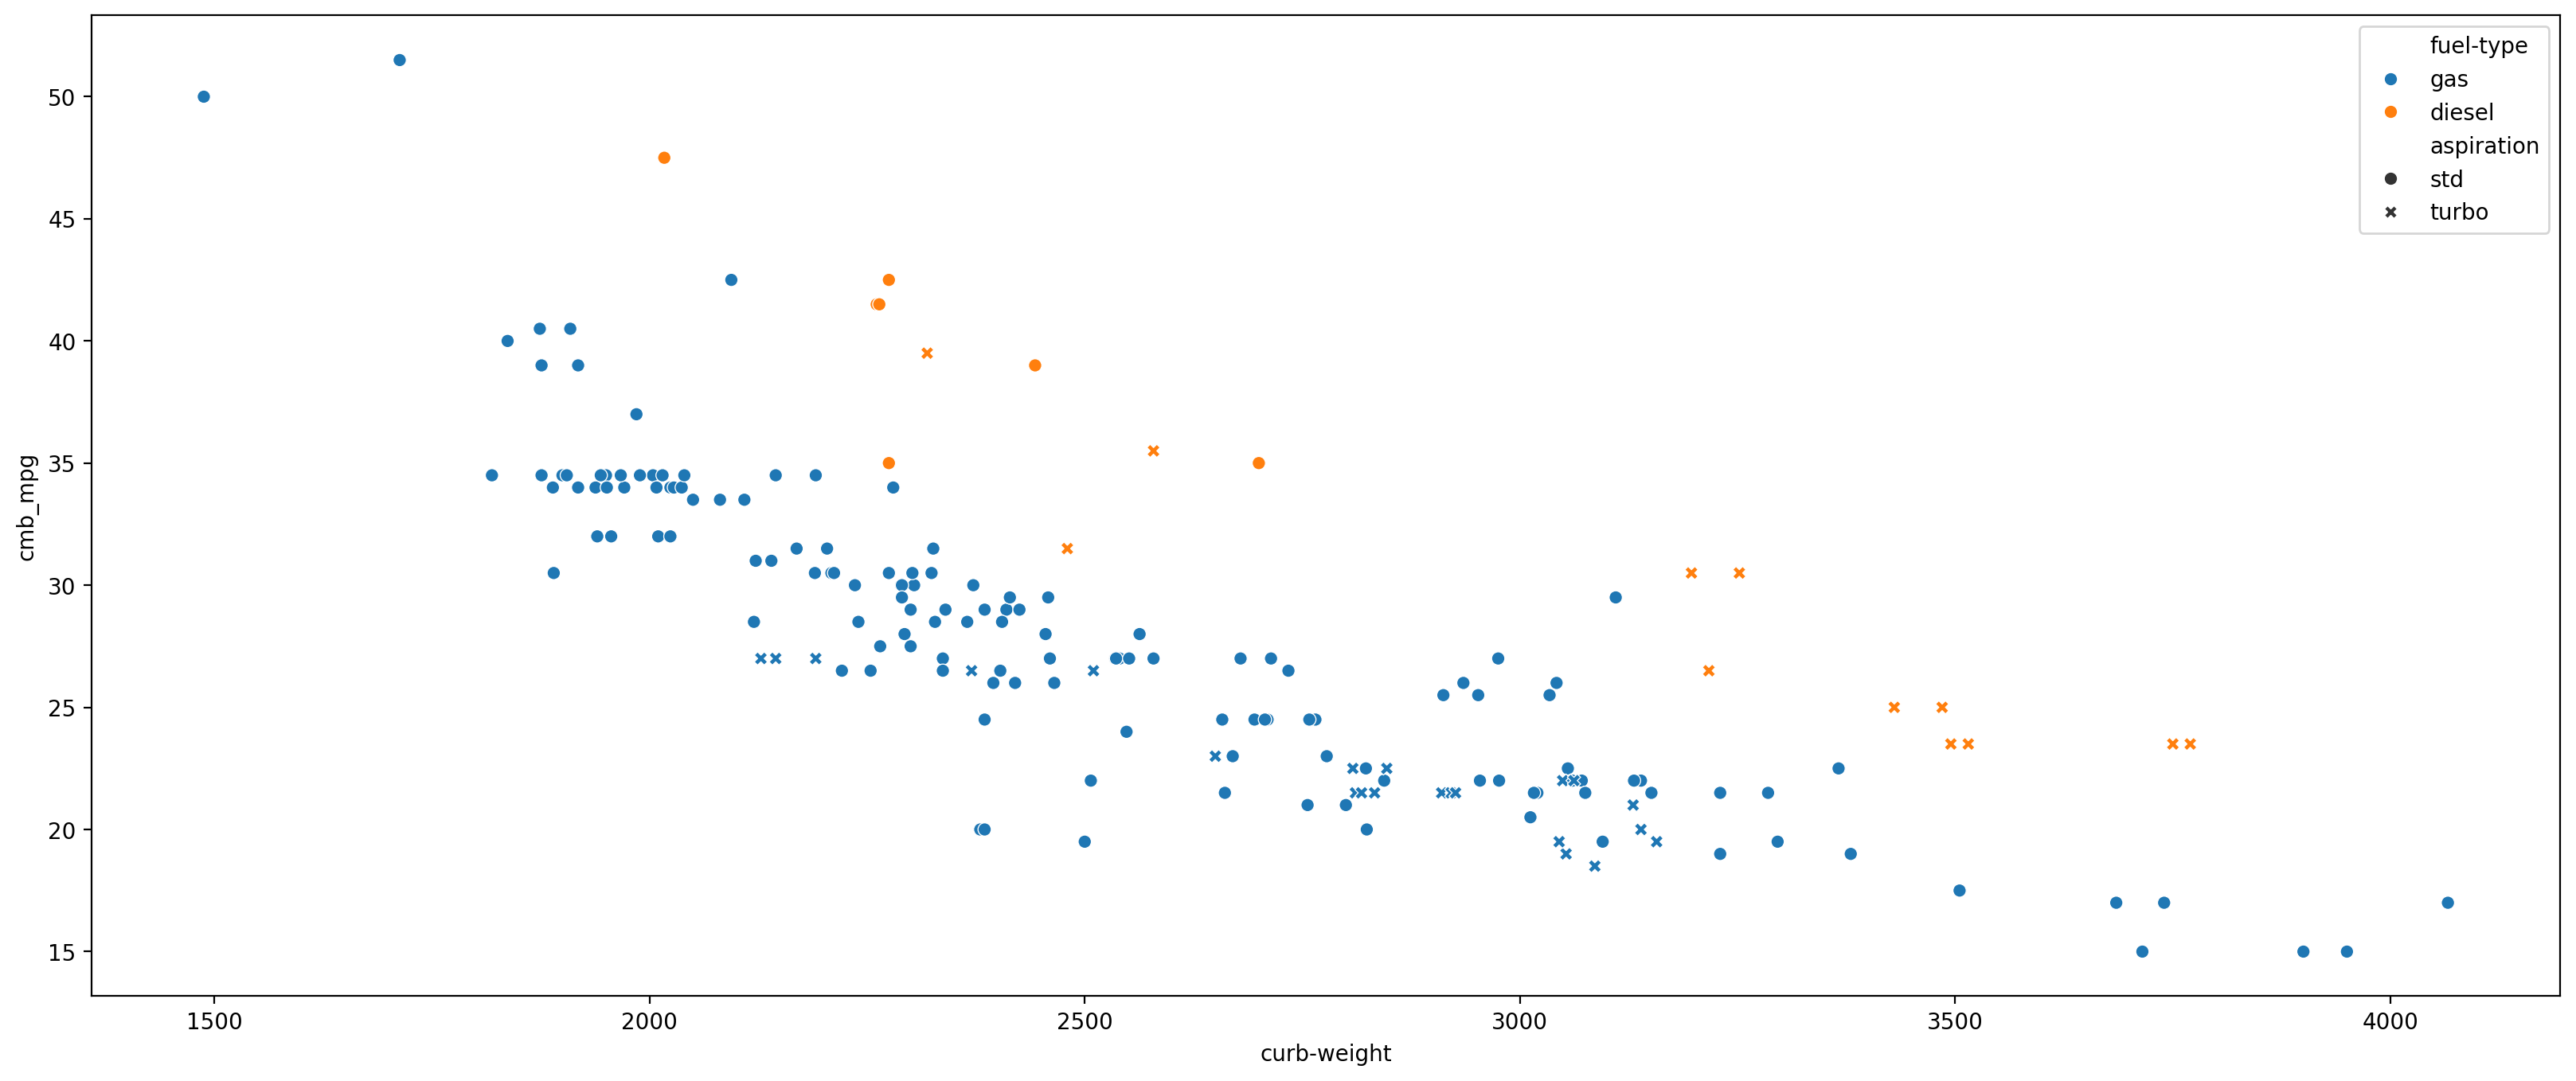

In [ ]:
plt.figure(figsize=(20,8),dpi=200)
sns.scatterplot(x='curb-weight',y='cmb_mpg', hue='fuel-type',style='aspiration',data=data)